In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import precision_recall_curve, average_precision_score

np.random.seed(42)

In [2]:
credit_df = pd.read_csv("C:\\Users\\ellak\\Downloads\\Data Science\\creditcard.csv")
credit_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
#splitting data into train/test 60/20/20
X_raw = credit_df 
y_raw = credit_df.pop("Class")
X_dev, X_test, y_dev, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev)
#standardize
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_val_scaled = scalar.fit_transform(X_val)
X_test_scaled= scalar.fit_transform(X_test)
print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Training set  : (170883, 30)
Validation set: (56962, 30)


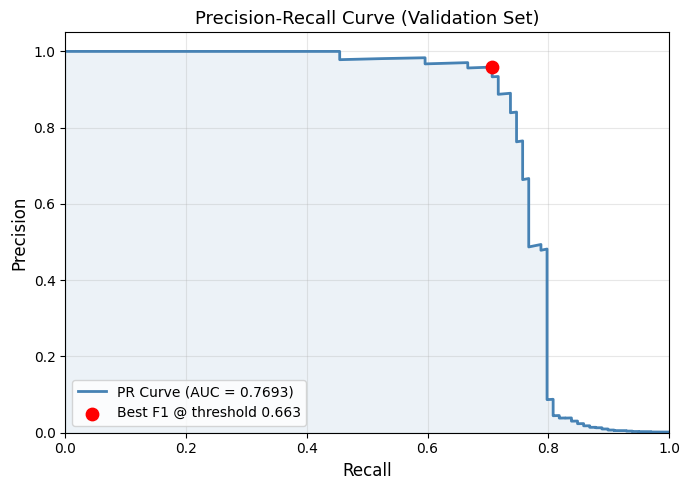

In [4]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_scores = mlp.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
pr_auc = average_precision_score(y_val, y_scores)
#f1 score at each threshold
f1_scores = 2 * (precision*recall)/(precision+recall)
best_threshold = thresholds[np.argmax(f1_scores)]
best_idx = np.argmax(f1_scores)
#graph for validation
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR Curve (AUC = {pr_auc:.4f})")
ax.fill_between(recall, precision, alpha=0.1, color="steelblue")
ax.scatter(recall[best_idx], precision[best_idx], color="red", zorder=5, s=80,
           label=f"Best F1 @ threshold {thresholds[best_idx]:.3f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(f"Precision-Recall Curve (Validation Set)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
#hyperparam tuning using random search
param_grid = {
    "hidden_layer_sizes": [(64,32), (128,64), (128,64,32), (256,128,64)],
    "alpha":              [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.0001],
    "batch_size":         [256, 512],
}

mlp = MLPClassifier(
    solver="adam",
    activation="relu",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

search = RandomizedSearchCV(
    mlp, param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train_scaled, y_train)  # raw imbalanced training data
print("Best params:", search.best_params_)
print("Best PR-AUC:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 256, 'alpha': 0.0001}
Best PR-AUC: 0.8392806887211496


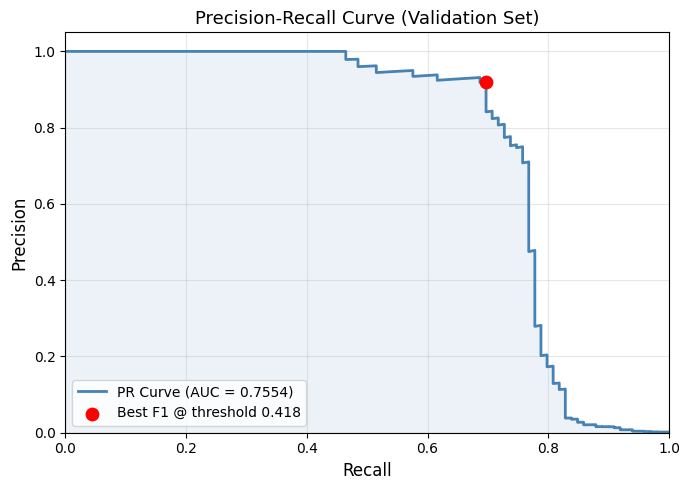

In [6]:
#update mlp
mlp = MLPClassifier(learning_rate_init =0.001,hidden_layer_sizes=(256,128,64), activation='relu', solver='adam', max_iter=1000, random_state=42, batch_size=256, alpha=0.001)
mlp.fit(X_train_scaled, y_train)
y_scores = mlp.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
pr_auc = average_precision_score(y_val, y_scores)
#f1 score at each threshold
f1_scores = 2 * (precision*recall)/(precision+recall)
best_threshold = thresholds[np.argmax(f1_scores)]
best_idx = np.argmax(f1_scores)
#graph for validation
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR Curve (AUC = {pr_auc:.4f})")
ax.fill_between(recall, precision, alpha=0.1, color="steelblue")
ax.scatter(recall[best_idx], precision[best_idx], color="red", zorder=5, s=80,
           label=f"Best F1 @ threshold {thresholds[best_idx]:.3f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(f"Precision-Recall Curve (Validation Set)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

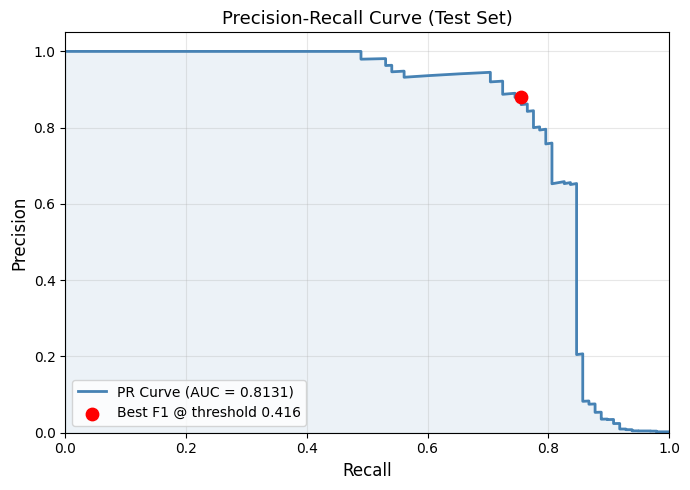

In [7]:
y_scores = mlp.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)
#f1 score at each threshold
f1_scores = 2 * (precision*recall)/(precision+recall)
best_threshold = thresholds[np.argmax(f1_scores)]
best_idx = np.argmax(f1_scores)
#graph for test
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR Curve (AUC = {pr_auc:.4f})")
ax.fill_between(recall, precision, alpha=0.1, color="steelblue")
ax.scatter(recall[best_idx], precision[best_idx], color="red", zorder=5, s=80,
           label=f"Best F1 @ threshold {thresholds[best_idx]:.3f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(f"Precision-Recall Curve (Test Set)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()